In [1]:
# Normalization
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data = pd.DataFrame({
    'A': [10, 20, 30, 40, 50],
    'B': [5, 15, 25, 35, 45]
})

scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(data)

normalized_df = pd.DataFrame(normalized_data, columns=data.columns)

print("Normalized Data (Min-Max Scaling):")
print(normalized_df)


Normalized Data (Min-Max Scaling):
      A     B
0  0.00  0.00
1  0.25  0.25
2  0.50  0.50
3  0.75  0.75
4  1.00  1.00


In [2]:
#  Standardization
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
standardized_data = scaler.fit_transform(data)

standardized_df = pd.DataFrame(standardized_data, columns=data.columns)

print("\nStandardized Data (Z-score):")
print(standardized_df)



Standardized Data (Z-score):
          A         B
0 -1.414214 -1.414214
1 -0.707107 -0.707107
2  0.000000  0.000000
3  0.707107  0.707107
4  1.414214  1.414214


In [3]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
import seaborn as sns
# Load dataset
tips = sns.load_dataset("tips")   # or pd.read_csv("tips.csv")
print("Original Data (first 5 rows):")
print(tips.head())
# 1. Normalization (Min-Max Scaling)
numeric_cols = tips.select_dtypes(include=['float64','int64']).columns
scaler_minmax = MinMaxScaler()
tips_normalized = tips.copy()
tips_normalized[numeric_cols] = scaler_minmax.fit_transform(tips[numeric_cols])
print("\nNormalized Data (first 5 rows):")
print(tips_normalized.head())
# 2. Standardization (Z-score)
scaler_standard = StandardScaler()
tips_standardized = tips.copy()
tips_standardized[numeric_cols] = scaler_standard.fit_transform(tips[numeric_cols])

print("\nStandardized Data (first 5 rows):")
print(tips_standardized.head())
# 3. Encoding Categorical Variables
# (a) One-Hot Encoding
tips_onehot = pd.get_dummies(tips, columns=['sex','smoker','day','time'])
print("\nOne-Hot Encoded Data (first 5 rows):")
print(tips_onehot.head())


Original Data (first 5 rows):
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Normalized Data (first 5 rows):
   total_bill       tip     sex smoker  day    time  size
0    0.291579  0.001111  Female     No  Sun  Dinner   0.2
1    0.152283  0.073333    Male     No  Sun  Dinner   0.4
2    0.375786  0.277778    Male     No  Sun  Dinner   0.4
3    0.431713  0.256667    Male     No  Sun  Dinner   0.2
4    0.450775  0.290000  Female     No  Sun  Dinner   0.6

Standardized Data (first 5 rows):
   total_bill       tip     sex smoker  day    time      size
0   -0.314711 -1.439947  Female     No  Sun  Dinner -0.600193
1   -1.063235 -0.969205    Male     No  Sun  Dinner  0.453383
2    0.137780  0.363356    Male     No  Sun 

In [4]:
# PCA
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

tips = sns.load_dataset("tips")

numeric_cols = tips.select_dtypes(include=['float64','int64'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_cols)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1','PC2'])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("\nPCA Result (first 5 rows):")
print(pca_df.head())


Explained variance ratio: [0.72627656 0.1730423 ]

PCA Result (first 5 rows):
        PC1       PC2
0 -1.348415  0.426746
1 -0.955740  1.093576
2  0.540971  0.122324
3  0.067789 -0.674616
4  1.408308  0.847661


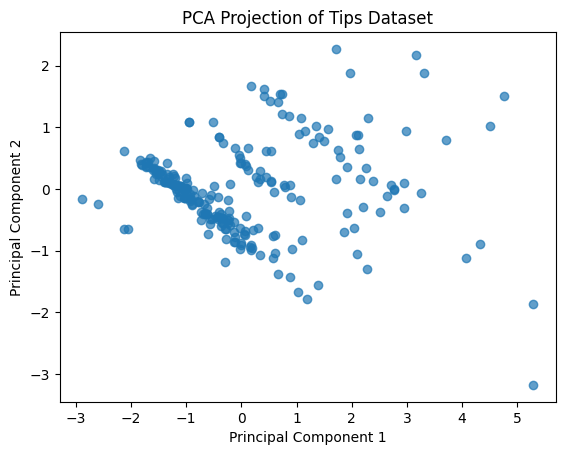

In [5]:
# Matplotlib
import matplotlib.pyplot as plt
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Tips Dataset')
plt.show()


Explained variance ratio: [0.9912126 0.0087874]

LDA Result (first 5 rows):
        LD1       LD2  target
0  8.061800 -0.300421       0
1  7.128688  0.786660       0
2  7.489828  0.265384       0
3  6.813201  0.670631       0
4  8.132309 -0.514463       0


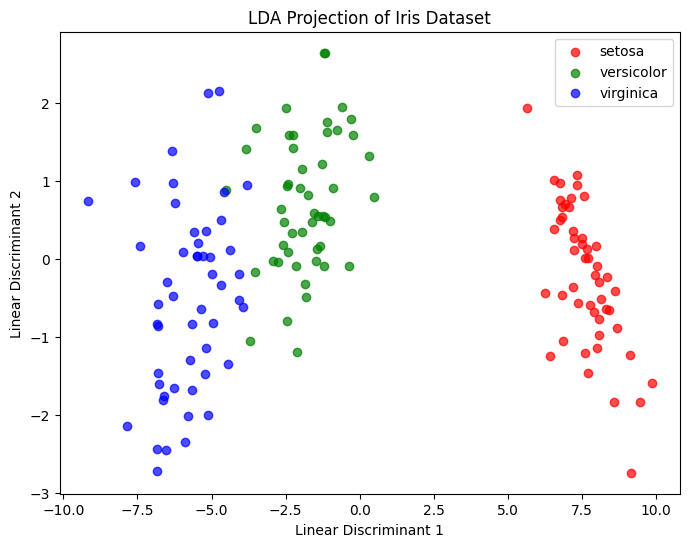

In [7]:
# LDA
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

lda_df = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
lda_df['target'] = y

print("Explained variance ratio:", lda.explained_variance_ratio_)
print("\nLDA Result (first 5 rows):")
print(lda_df.head())

plt.figure(figsize=(8,6))
for label, color in zip([0,1,2], ['red','green','blue']):
    plt.scatter(
        lda_df.loc[lda_df['target']==label, 'LD1'],
        lda_df.loc[lda_df['target']==label, 'LD2'],
        label=iris.target_names[label],
        color=color,
        alpha=0.7
    )

plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.title('LDA Projection of Iris Dataset')
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE Result (first 5 rows):
       TSNE1     TSNE2  target
0 -24.284670 -0.196069       0
1 -21.731905  0.653882       0
2 -21.776773 -0.433848       0
3 -21.413086 -0.141203       0
4 -24.284908 -0.606254       0


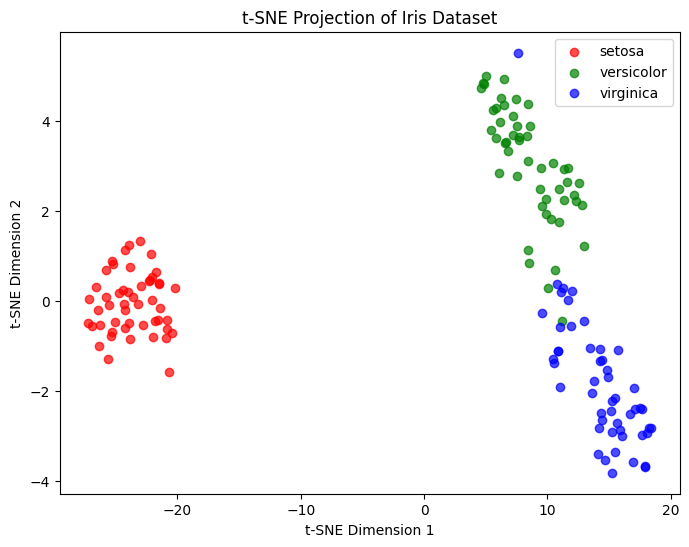

In [8]:
# TSNE
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X)

tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['target'] = y

print("t-SNE Result (first 5 rows):")
print(tsne_df.head())

plt.figure(figsize=(8,6))
for label, color in zip([0,1,2], ['red','green','blue']):
    plt.scatter(
        tsne_df.loc[tsne_df['target']==label, 'TSNE1'],
        tsne_df.loc[tsne_df['target']==label, 'TSNE2'],
        label=iris.target_names[label],
        color=color,
        alpha=0.7
    )

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Projection of Iris Dataset')
plt.legend()
plt.show()
